TABLA 1: Resumen por Unidad de Compra


,Unidad de Compra,cantidad_registros,monto_total,monto_promedio,cantidad_oc
0,Ministerio de Vivienda y Urbanismo(766),684,81943911910,1.198010e+08,743
8,SEREMI MINVU V REGION,30,1187465518,3.958218e+07,76
5,SEREMI MINVU III REGION,25,309240000,1.236960e+07,39
14,SERVICIO DE BIENESTAR MINVU SERVIU,4,248000000,6.200000e+07,4
9,SEREMI MINVU VI REGION,20,162228246,8.111412e+06,38
6,SEREMI MINVU REGION ARICA Y PARINACOTA,9,135080000,1.500889e+07,20
4,SEREMI MINVU II REGION,8,112600006,1.407500e+07,14
12,SEREMI VIII REGION,6,109333336,1.822222e+07,14
7,SEREMI MINVU RM,3,37427780,1.247593e+07,6
11,SEREMI MINVU XI REGION,8,19992000,2.499000e+06,32


TABLA 2: Resumen por Tipo de Proyecto


,Tipo Proyecto,cantidad_registros,monto_total,monto_promedio
1,Proyecto operacional,613,77138651126,1.258379e+08
0,Proyecto estratégico,218,7195631224,3.300748e+07


TABLA 3: Resumen por Tipo de Compra


,Tipo compra,cantidad_registros,monto_total,monto_promedio,cantidad_oc
5,6,486,67870307246,1.396508e+08,498
0,1,159,4921854535,3.095506e+07,423
3,4,83,3921795608,4.725055e+07,83
4,5,79,7440038312,9.417770e+07,79
2,3,20,56552759,2.827638e+06,29
1,2,4,123733890,3.093347e+07,5


TABLA 4: Resumen mensual por Fecha de Inicio Compra


,anio_mes,cantidad_registros,monto_total
0,2022-02,1,4500000
1,2022-08,2,8325000
2,2022-11,1,20000000
3,2022-12,7,62441580
4,2023-01,9,41612149
5,2023-02,4,64776207
6,2023-03,15,93351556
7,2023-04,22,411766478
8,2023-05,4,7000682
9,2023-06,7,239668689


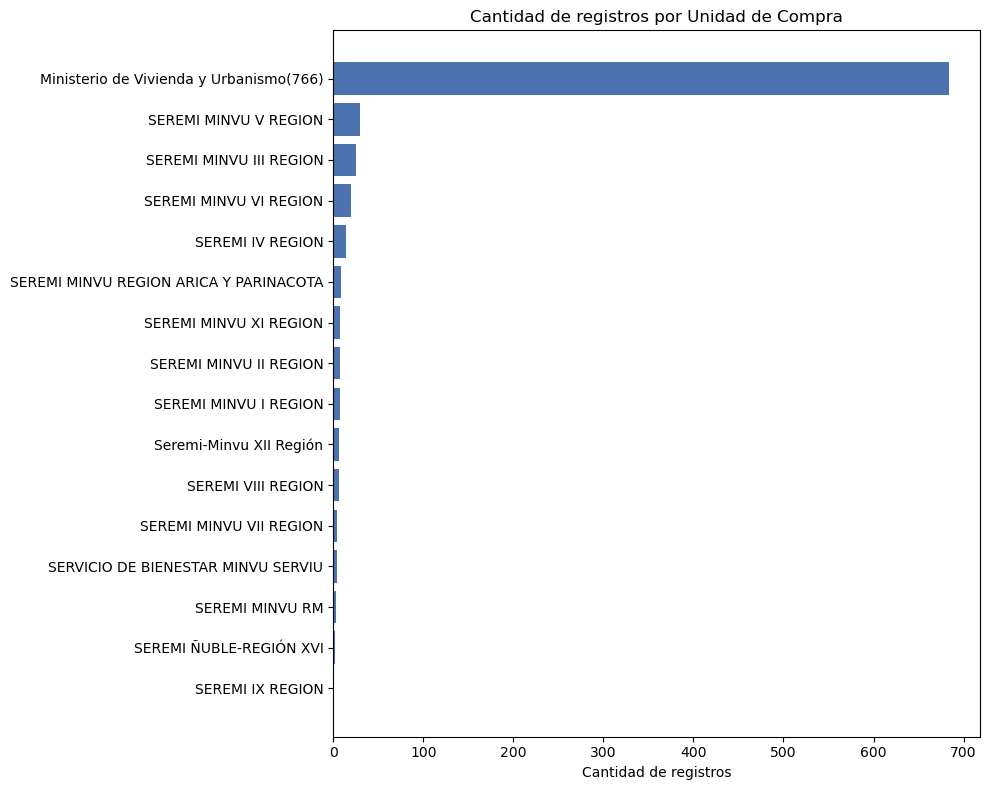

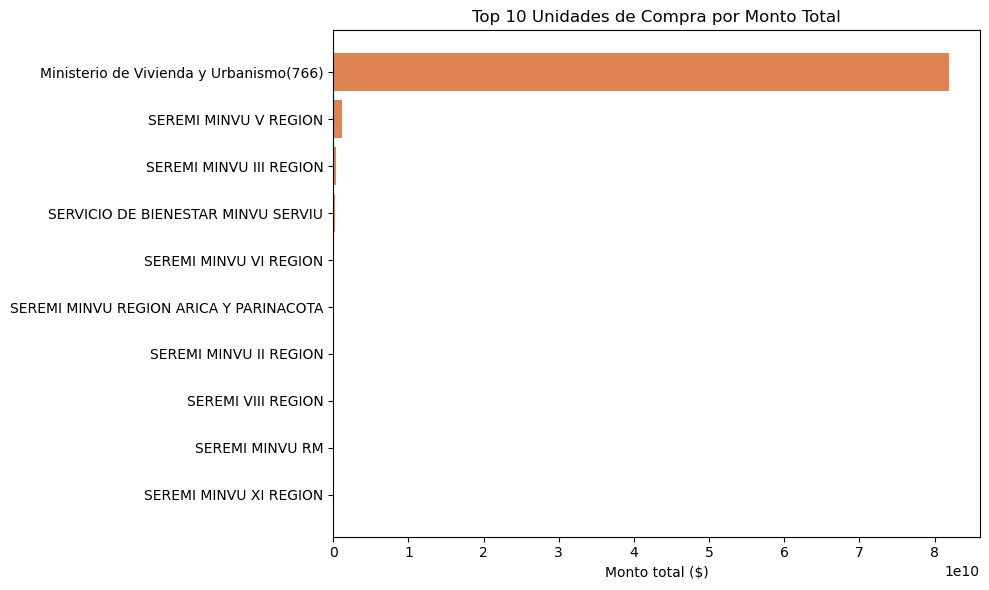

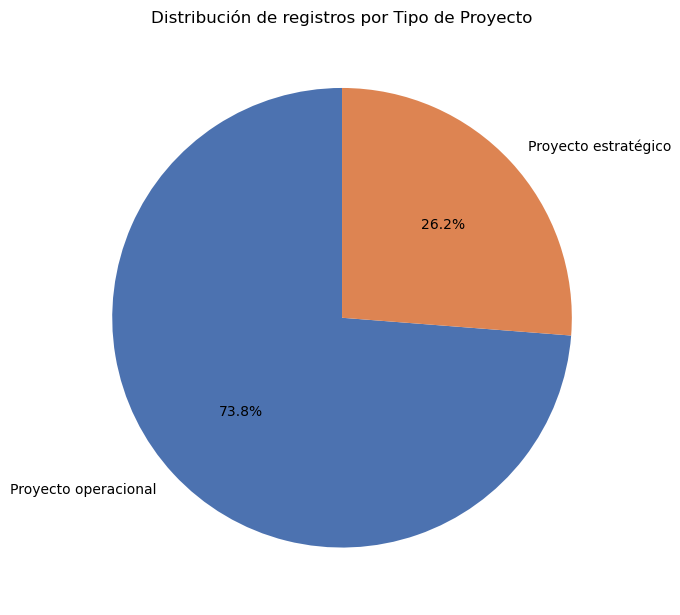

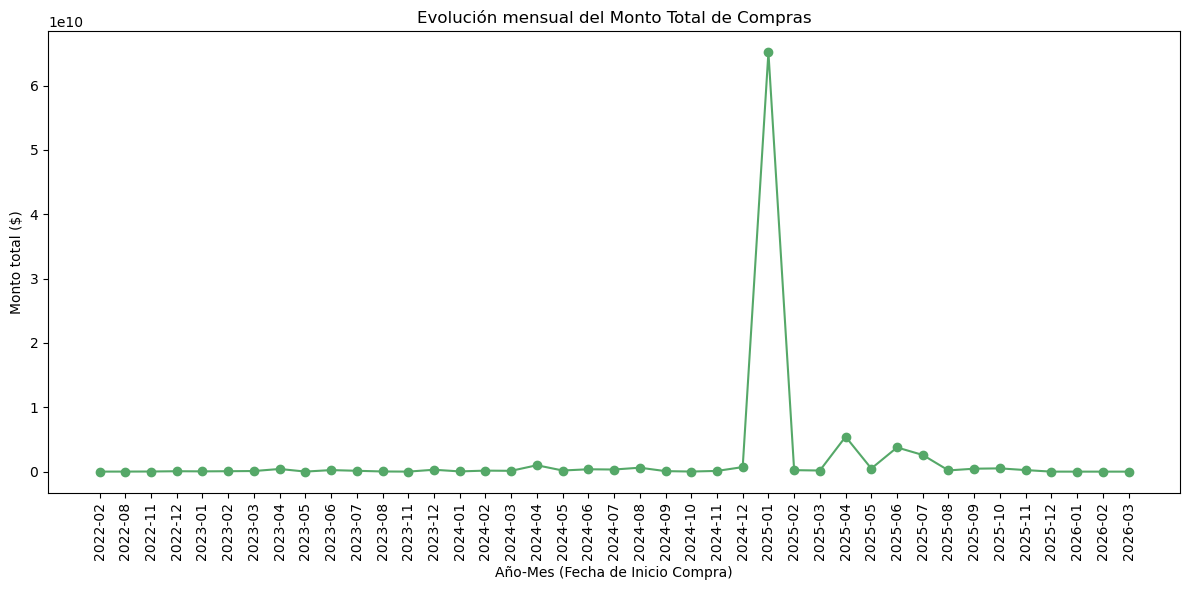

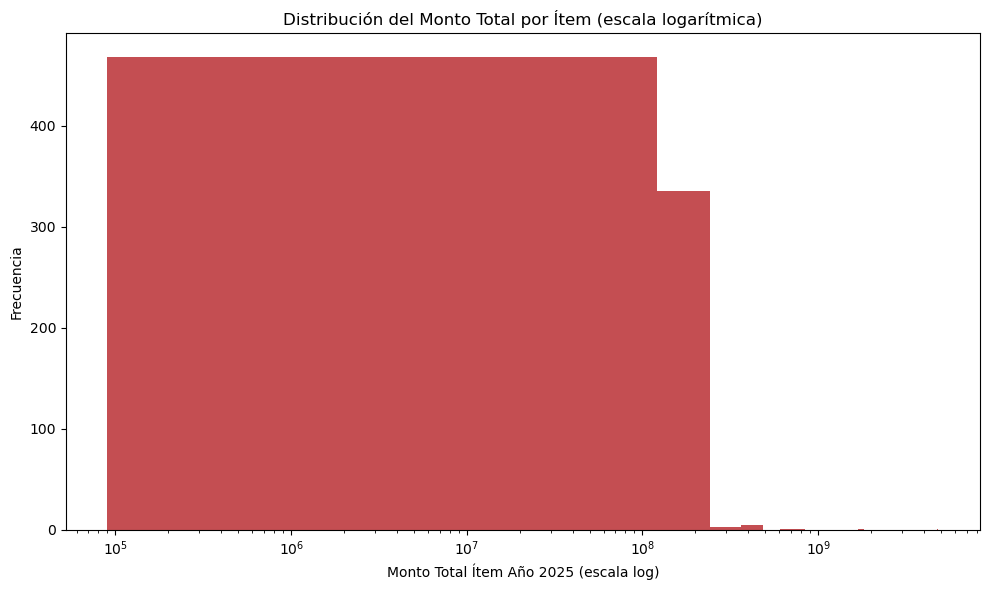

In [ ]:
# ============================================================
# Felipe Vallejos
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

df = pd.read_excel("../plan_de_compras_2025.xlsx")

COL_UNIDAD   = "Unidad de Compra"
COL_TIPO_PRY = "Tipo Proyecto"
COL_TIPO_CPA = "Tipo compra"
COL_MONTO    = "Monto Total Ítem Año 2025"
COL_OC       = "Cantidad OC"
COL_FECHA    = "Fecha de Inicio Compra"

# ============================================================
# 2. TABLAS RESUMEN
# ============================================================

# --- Tabla 1: resumen por Unidad de Compra ---
tabla_unidad = (
    df.groupby(COL_UNIDAD)
      .agg(cantidad_registros=(COL_UNIDAD, "size"),
           monto_total=(COL_MONTO, "sum"),
           monto_promedio=(COL_MONTO, "mean"),
           cantidad_oc=(COL_OC, "sum"))
      .reset_index()
      .sort_values("monto_total", ascending=False)
)
print("TABLA 1: Resumen por Unidad de Compra")
display(tabla_unidad)

# --- Tabla 2: resumen por Tipo de Proyecto ---
tabla_tipo_proyecto = (
    df.groupby(COL_TIPO_PRY)
      .agg(cantidad_registros=(COL_TIPO_PRY, "size"),
           monto_total=(COL_MONTO, "sum"),
           monto_promedio=(COL_MONTO, "mean"))
      .reset_index()
      .sort_values("monto_total", ascending=False)
)
print("TABLA 2: Resumen por Tipo de Proyecto")
display(tabla_tipo_proyecto)

# --- Tabla 3: resumen por Tipo de compra ---
tabla_tipo_compra = (
    df.groupby(COL_TIPO_CPA)
      .agg(cantidad_registros=(COL_TIPO_CPA, "size"),
           monto_total=(COL_MONTO, "sum"),
           monto_promedio=(COL_MONTO, "mean"),
           cantidad_oc=(COL_OC, "sum"))
      .reset_index()
      .sort_values("cantidad_registros", ascending=False)
)
print("TABLA 3: Resumen por Tipo de Compra")
display(tabla_tipo_compra)

# --- Tabla 4: resumen mensual (por Fecha de Inicio Compra) ---
df["anio_mes"] = df[COL_FECHA].dt.to_period("M").astype(str)
tabla_mensual = (
    df.groupby("anio_mes")
      .agg(cantidad_registros=("anio_mes", "size"),
           monto_total=(COL_MONTO, "sum"))
      .reset_index()
      .sort_values("anio_mes")
)
print("TABLA 4: Resumen mensual por Fecha de Inicio Compra")
display(tabla_mensual)

# ============================================================
# 3. GRAFICOS RESUMEN
# ============================================================

# --- Grafico 1: cantidad de registros por Unidad de Compra ---
resumen1 = tabla_unidad.sort_values("cantidad_registros", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(resumen1[COL_UNIDAD], resumen1["cantidad_registros"], color="#4C72B0")
plt.xlabel("Cantidad de registros")
plt.title("Cantidad de registros por Unidad de Compra")
plt.tight_layout()
plt.show()

# --- Grafico 2: monto total por Unidad de Compra (top 10) ---
top10 = tabla_unidad.nlargest(10, "monto_total").sort_values("monto_total")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10[COL_UNIDAD], top10["monto_total"], color="#DD8452")
ax.set_xlabel("Monto total ($)")
ax.set_title("Top 10 Unidades de Compra por Monto Total")
plt.tight_layout()
plt.show()

# --- Grafico 3: distribucion por Tipo de Proyecto (torta) ---
plt.figure(figsize=(7, 7))
plt.pie(tabla_tipo_proyecto["cantidad_registros"], labels=tabla_tipo_proyecto[COL_TIPO_PRY],
        autopct="%1.1f%%", colors=["#4C72B0", "#DD8452", "#55A868"], startangle=90)
plt.title("Distribución de registros por Tipo de Proyecto")
plt.tight_layout()
plt.show()

# --- Grafico 4: evolucion mensual del monto total de compras ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(tabla_mensual["anio_mes"], tabla_mensual["monto_total"], marker="o", color="#55A868")
ax.set_xlabel("Año-Mes (Fecha de Inicio Compra)")
ax.set_ylabel("Monto total ($)")
ax.set_title("Evolución mensual del Monto Total de Compras")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# --- Grafico 5: distribucion del Monto Total por Item (histograma log) ---
plt.figure(figsize=(10, 6))
plt.hist(df[df[COL_MONTO] > 0][COL_MONTO], bins=40, color="#C44E52")
plt.xscale("log")
plt.xlabel("Monto Total Ítem Año 2025 (escala log)")
plt.ylabel("Frecuencia")
plt.title("Distribución del Monto Total por Ítem (escala logarítmica)")
plt.tight_layout()
plt.show()